# 기존 MLP와 같은 구조 실험

목표: `04_similarity_feature_mlp_confidence.ipynb`의 입력 feature를 사용하되, 모델 구조는 `confidence 분류기 5-17실험/bsd10k_confidence_mlp_colab.ipynb`의 실제 classification 코드와 동일하게 맞춘다.

모델 구조:

```python
Dropout(dropout)
Linear(input_dim, 5)
```

즉 hidden layer가 없는 input dropout + linear classifier 구조이다.

In [1]:
from pathlib import Path
import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')

SEED = 42
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_VALUES = [0.8, 0.7, 0.6, 0.5,0.4,0.3,0.2]
VAL_SIZE = 0.2
NUM_WORKERS = 0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('DEVICE:', DEVICE)

DEVICE: cuda


## 경로 설정

In [2]:
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd().resolve()

if HERE.name == 'deft논문기반_실험':
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

METADATA_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
TEXT_SIM_CSV = EXP_DIR / 'audio_text_sim_confidence_outputs' / 'audio_text_similarity_with_bin_predictions.csv'
CLASS_SIM_CSV = EXP_DIR / 'audio_class_sim_confidence_outputs' / 'audio_class_similarity_with_bin_predictions.csv'
MARGIN_CSV = EXP_DIR / 'clap_similarity_margin_outputs' / 'clap_similarity_margin_features.csv'

OUT_DIR = EXP_DIR / 'same_structure_mlp_confidence_outputs'
PLOT_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('EXP_DIR:', EXP_DIR)
print('OUT_DIR:', OUT_DIR)
for path in [METADATA_CSV, AUDIO_EMB_DIR, TEXT_EMB_DIR, TEXT_SIM_CSV, CLASS_SIM_CSV, MARGIN_CSV]:
    print(path, 'exists:', path.exists())

ROOT: C:\Users\solok\Desktop\Dcase baseline
EXP_DIR: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험
OUT_DIR: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\same_structure_mlp_confidence_outputs
C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_text_sim_confidence_outputs\audio_text_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs\audio_class_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs\clap_similarity_margin_features.csv exists: True


## 04와 동일한 입력 feature 생성

- CLAP audio embedding 512
- CLAP text embedding 512
- class one-hot
- similarity/margin scalar 4개

In [3]:
LABELS = [1, 2, 3, 4, 5]
SCALAR_FEATURE_COLS = [
    'audio_text_sim',
    'audio_class_sim',
    'audio_assigned_label_margin',
    'text_assigned_label_margin',
]
FEATURE_DESCRIPTION = 'audio_embedding_512 + text_embedding_512 + class_one_hot + similarity_margin_4'
MODEL_DESCRIPTION = 'Dropout(dropout) -> Linear(input_dim, 5)'

meta = pd.read_csv(METADATA_CSV)
required_cols = ['sound_id', 'class', 'confidence']
missing_cols = [c for c in required_cols if c not in meta.columns]
if missing_cols:
    raise ValueError(f'metadata에 필요한 컬럼이 없습니다: {missing_cols}')

audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}

rows = []
audio_list = []
text_list = []
missing_audio = 0
missing_text = 0
invalid_confidence = 0

for _, row in meta.iterrows():
    sound_id = str(row['sound_id'])
    audio_path = audio_paths.get(sound_id)
    text_path = text_paths.get(sound_id)
    if audio_path is None:
        missing_audio += 1
        continue
    if text_path is None:
        missing_text += 1
        continue
    try:
        confidence = int(row['confidence'])
    except Exception:
        invalid_confidence += 1
        continue
    if confidence not in LABELS:
        invalid_confidence += 1
        continue

    audio_vec = np.load(audio_path).reshape(-1).astype(np.float32)
    text_vec = np.load(text_path).reshape(-1).astype(np.float32)
    rows.append({
        'sound_id': sound_id,
        'class': row['class'],
        'confidence': confidence,
    })
    audio_list.append(audio_vec)
    text_list.append(text_vec)

df = pd.DataFrame(rows)
df['_row_idx'] = np.arange(len(df))
audio_emb = np.stack(audio_list).astype(np.float32)
text_emb = np.stack(text_list).astype(np.float32)

text_sim_df = pd.read_csv(TEXT_SIM_CSV)[['sound_id', 'audio_text_sim']]
class_sim_df = pd.read_csv(CLASS_SIM_CSV)[['sound_id', 'audio_class_sim']]
margin_df = pd.read_csv(MARGIN_CSV)[['sound_id', 'audio_assigned_label_margin', 'text_assigned_label_margin']]
for part_df in [text_sim_df, class_sim_df, margin_df]:
    part_df['sound_id'] = part_df['sound_id'].astype(str)

df = df.merge(text_sim_df, on='sound_id', how='left')
df = df.merge(class_sim_df, on='sound_id', how='left')
df = df.merge(margin_df, on='sound_id', how='left')
missing_scalar = int(df[SCALAR_FEATURE_COLS].isna().any(axis=1).sum())
df = df.dropna(subset=SCALAR_FEATURE_COLS).reset_index(drop=True)

keep_idx = df['_row_idx'].to_numpy(dtype=np.int64)
audio_emb = audio_emb[keep_idx]
text_emb = text_emb[keep_idx]
scalar_features = df[SCALAR_FEATURE_COLS].to_numpy(dtype=np.float32)

class_categories = sorted(df['class'].unique().tolist())
class_to_idx = {name: idx for idx, name in enumerate(class_categories)}
class_ids = df['class'].map(class_to_idx).to_numpy(dtype=np.int64)
class_onehot = np.eye(len(class_categories), dtype=np.float32)[class_ids]

X_full = np.concatenate([audio_emb, text_emb, class_onehot, scalar_features], axis=1).astype(np.float32)
y = (df['confidence'].to_numpy(dtype=np.int64) - 1)
df['class_idx'] = class_ids
df = df.drop(columns=['_row_idx'])

df.to_csv(OUT_DIR / 'dataset_index.csv', index=False, encoding='utf-8-sig')
np.save(OUT_DIR / 'X_audio_text_class_similarity_margin.npy', X_full)
(OUT_DIR / 'class_mapping.json').write_text(json.dumps(class_to_idx, indent=2, ensure_ascii=False), encoding='utf-8')

print('rows:', len(df))
print('missing audio:', missing_audio)
print('missing text:', missing_text)
print('invalid confidence:', invalid_confidence)
print('missing scalar features:', missing_scalar)
print('audio_emb shape:', audio_emb.shape)
print('text_emb shape:', text_emb.shape)
print('class_onehot shape:', class_onehot.shape)
print('scalar_features shape:', scalar_features.shape)
print('X_full shape:', X_full.shape)
display(df[['sound_id', 'class', 'class_idx', 'confidence'] + SCALAR_FEATURE_COLS].head())
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

rows: 10956
missing audio: 0
missing text: 0
invalid confidence: 0
missing scalar features: 0
audio_emb shape: (10956, 512)
text_emb shape: (10956, 512)
class_onehot shape: (10956, 23)
scalar_features shape: (10956, 4)
X_full shape: (10956, 1051)


,sound_id,class,class_idx,confidence,audio_text_sim,audio_class_sim,audio_assigned_label_margin,text_assigned_label_margin
0,185755,fx-o,6,4,0.591202,0.206392,0.046245,0.045049
1,358405,is-w,12,5,0.597089,0.105113,0.004585,-0.182870
2,358760,is-w,12,4,0.630050,-0.063060,-0.245459,-0.280030
3,432206,fx-o,6,4,0.637595,-0.160971,-0.360327,-0.295929
4,80630,sp-s,18,5,0.501695,0.203966,0.072325,-0.093477


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


## Train/validation split + scaling

`bsd10k_confidence_mlp_colab.ipynb`와 맞추기 위해 80/20 stratified validation split을 사용한다.

In [4]:
idx = np.arange(len(df))
train_idx, val_idx = train_test_split(
    idx,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y,
)

split_df = pd.DataFrame({'sound_id': df['sound_id'], 'split': 'train'})
split_df.loc[val_idx, 'split'] = 'val'
split_df.to_csv(OUT_DIR / 'splits.csv', index=False, encoding='utf-8-sig')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_full[train_idx]).astype(np.float32)
X_val = scaler.transform(X_full[val_idx]).astype(np.float32)
y_train = y[train_idx]
y_val = y[val_idx]

print('train/val:', len(train_idx), len(val_idx))
display(pd.crosstab(split_df['split'], df['confidence'], rownames=['split'], colnames=['confidence']))

train/val: 8764 2192


confidence,1,2,3,4,5
split,,,,,
train,85,599,2624,4835,621
val,21,150,656,1210,155


## 모델/학습 함수

아래 `SameStructureMLP`가 5-17 classification 노트북의 실제 `SimpleMLP`와 같은 구조이다.

In [5]:
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SameStructureMLP(nn.Module):
    def __init__(self, input_dim, num_outputs=5, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, num_outputs),
        )

    def forward(self, x):
        return self.net(x)


def compute_classification_metrics(y_true, y_pred):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'acc': accuracy_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true + 1, y_pred + 1),
        'mse': mean_squared_error(y_true + 1, y_pred + 1),
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro,
        'precision_weighted': p_weighted,
        'recall_weighted': r_weighted,
        'f1_weighted': f1_weighted,
    }


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_pred = []
    all_prob = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.softmax(logits, dim=1)
            pred = prob.argmax(dim=1)
            total_loss += loss.item() * len(yb)
            all_true.append(yb.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            all_prob.append(prob.cpu().numpy())
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    metrics = compute_classification_metrics(y_true, y_pred)
    metrics['loss'] = total_loss / len(y_true)
    return metrics, y_true, y_pred, y_prob


def train_one_dropout(dropout):
    seed_everything(SEED)
    print(f'\n===== dropout={dropout} =====')
    train_ds = FeatureDataset(X_train, y_train)
    val_ds = FeatureDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = SameStructureMLP(input_dim=X_full.shape[1], num_outputs=5, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_f1 = -1.0
    best_epoch = None
    best_state = None
    best_predictions = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(yb)
        train_loss /= len(train_ds)

        val_metrics, y_true, y_pred, y_prob = evaluate(model, val_loader, criterion)
        history.append({'epoch': epoch, 'train_loss': train_loss, **val_metrics})

        if val_metrics['f1_macro'] > best_f1:
            best_f1 = val_metrics['f1_macro']
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_predictions = {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"acc={val_metrics['acc']:.4f} | "
            f"mae={val_metrics['mae']:.4f} | "
            f"f1={val_metrics['f1_macro']:.4f}"
        )

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_DIR / f'history_dropout_{dropout:.1f}.csv', index=False, encoding='utf-8-sig')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
    ax.plot(history_df['epoch'], history_df['loss'], label='validation loss')
    ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'best epoch {best_epoch}')
    ax.set_title(f'same-structure MLP dropout={dropout:.1f}')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f'loss_dropout_{dropout:.1f}.png', dpi=160)
    plt.show()

    best_metrics = compute_classification_metrics(best_predictions['y_true'], best_predictions['y_pred'])
    best_metrics['best_epoch'] = best_epoch
    best_metrics['dropout'] = dropout
    return {
        'model': model,
        'metrics': best_metrics,
        'history': history_df,
        'predictions': best_predictions,
        'dropout': dropout,
    }

## Dropout sweep 실행


===== dropout=0.8 =====
Epoch 01/30 | train_loss=1.8677 | val_loss=1.4701 | acc=0.4498 | mae=0.6811 | f1=0.3143
Epoch 02/30 | train_loss=1.5930 | val_loss=1.4055 | acc=0.4881 | mae=0.5899 | f1=0.3185
Epoch 03/30 | train_loss=1.4825 | val_loss=1.3612 | acc=0.5050 | mae=0.5598 | f1=0.3287
Epoch 04/30 | train_loss=1.4442 | val_loss=1.3168 | acc=0.5059 | mae=0.5584 | f1=0.3151
Epoch 05/30 | train_loss=1.3992 | val_loss=1.2829 | acc=0.5333 | mae=0.5233 | f1=0.3397
Epoch 06/30 | train_loss=1.3603 | val_loss=1.2470 | acc=0.5370 | mae=0.5119 | f1=0.3238
Epoch 07/30 | train_loss=1.3314 | val_loss=1.2235 | acc=0.5374 | mae=0.5100 | f1=0.3216
Epoch 08/30 | train_loss=1.2862 | val_loss=1.1955 | acc=0.5374 | mae=0.5123 | f1=0.3120
Epoch 09/30 | train_loss=1.2781 | val_loss=1.1710 | acc=0.5370 | mae=0.5141 | f1=0.3097
Epoch 10/30 | train_loss=1.2384 | val_loss=1.1485 | acc=0.5506 | mae=0.4968 | f1=0.3233
Epoch 11/30 | train_loss=1.2227 | val_loss=1.1306 | acc=0.5593 | mae=0.4836 | f1=0.3114
Epoch 1

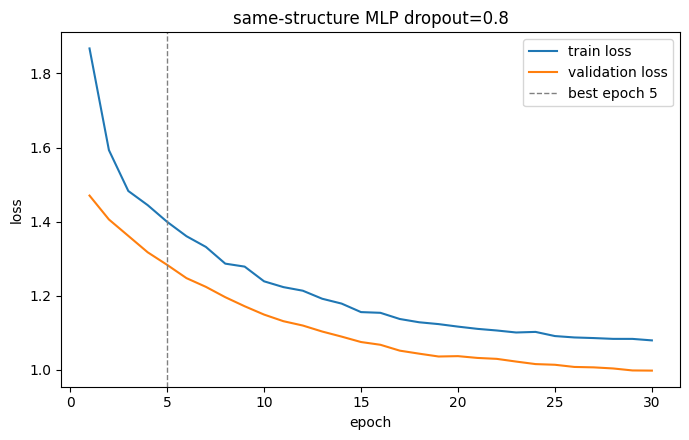


===== dropout=0.7 =====
Epoch 01/30 | train_loss=1.7569 | val_loss=1.4657 | acc=0.4535 | mae=0.6688 | f1=0.3223
Epoch 02/30 | train_loss=1.5517 | val_loss=1.4045 | acc=0.4822 | mae=0.6026 | f1=0.3312
Epoch 03/30 | train_loss=1.4566 | val_loss=1.3575 | acc=0.5123 | mae=0.5652 | f1=0.3487
Epoch 04/30 | train_loss=1.4146 | val_loss=1.3108 | acc=0.5014 | mae=0.5643 | f1=0.3205
Epoch 05/30 | train_loss=1.3683 | val_loss=1.2792 | acc=0.5251 | mae=0.5287 | f1=0.3338
Epoch 06/30 | train_loss=1.3293 | val_loss=1.2424 | acc=0.5301 | mae=0.5155 | f1=0.3274
Epoch 07/30 | train_loss=1.3020 | val_loss=1.2211 | acc=0.5328 | mae=0.5128 | f1=0.3280
Epoch 08/30 | train_loss=1.2683 | val_loss=1.1922 | acc=0.5470 | mae=0.4991 | f1=0.3285
Epoch 09/30 | train_loss=1.2461 | val_loss=1.1675 | acc=0.5388 | mae=0.5105 | f1=0.3186
Epoch 10/30 | train_loss=1.2183 | val_loss=1.1411 | acc=0.5502 | mae=0.4954 | f1=0.3281
Epoch 11/30 | train_loss=1.1942 | val_loss=1.1266 | acc=0.5602 | mae=0.4845 | f1=0.3161
Epoch 1

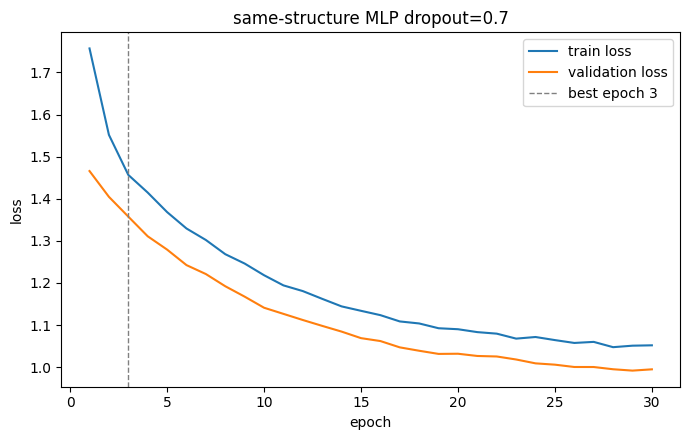


===== dropout=0.6 =====
Epoch 01/30 | train_loss=1.6961 | val_loss=1.4618 | acc=0.4557 | mae=0.6756 | f1=0.3232
Epoch 02/30 | train_loss=1.5265 | val_loss=1.4015 | acc=0.4863 | mae=0.5999 | f1=0.3315
Epoch 03/30 | train_loss=1.4444 | val_loss=1.3538 | acc=0.5064 | mae=0.5725 | f1=0.3413
Epoch 04/30 | train_loss=1.3862 | val_loss=1.3077 | acc=0.5068 | mae=0.5593 | f1=0.3243
Epoch 05/30 | train_loss=1.3473 | val_loss=1.2771 | acc=0.5246 | mae=0.5333 | f1=0.3303
Epoch 06/30 | train_loss=1.3063 | val_loss=1.2440 | acc=0.5342 | mae=0.5128 | f1=0.3306
Epoch 07/30 | train_loss=1.2824 | val_loss=1.2209 | acc=0.5287 | mae=0.5187 | f1=0.3251
Epoch 08/30 | train_loss=1.2501 | val_loss=1.1907 | acc=0.5406 | mae=0.5064 | f1=0.3254
Epoch 09/30 | train_loss=1.2255 | val_loss=1.1610 | acc=0.5379 | mae=0.5123 | f1=0.3201
Epoch 10/30 | train_loss=1.1984 | val_loss=1.1366 | acc=0.5547 | mae=0.4936 | f1=0.3347
Epoch 11/30 | train_loss=1.1787 | val_loss=1.1215 | acc=0.5625 | mae=0.4863 | f1=0.3248
Epoch 1

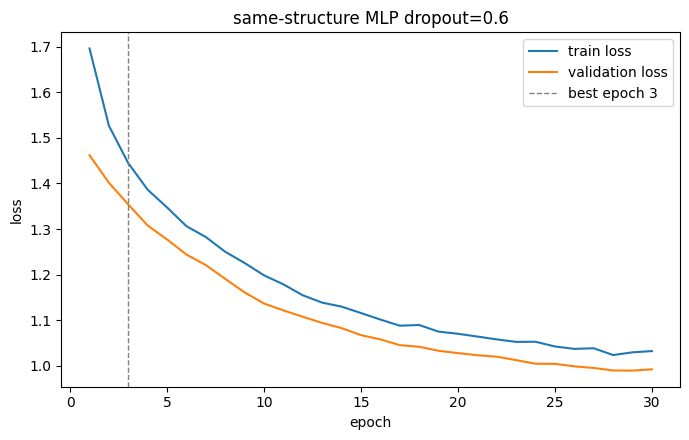


===== dropout=0.5 =====
Epoch 01/30 | train_loss=1.6551 | val_loss=1.4609 | acc=0.4521 | mae=0.6747 | f1=0.3202
Epoch 02/30 | train_loss=1.5060 | val_loss=1.3982 | acc=0.4818 | mae=0.6118 | f1=0.3359
Epoch 03/30 | train_loss=1.4298 | val_loss=1.3535 | acc=0.5078 | mae=0.5689 | f1=0.3478
Epoch 04/30 | train_loss=1.3713 | val_loss=1.3042 | acc=0.5073 | mae=0.5620 | f1=0.3404
Epoch 05/30 | train_loss=1.3333 | val_loss=1.2723 | acc=0.5297 | mae=0.5315 | f1=0.3350
Epoch 06/30 | train_loss=1.2919 | val_loss=1.2371 | acc=0.5415 | mae=0.5050 | f1=0.3343
Epoch 07/30 | train_loss=1.2661 | val_loss=1.2176 | acc=0.5347 | mae=0.5146 | f1=0.3256
Epoch 08/30 | train_loss=1.2349 | val_loss=1.1888 | acc=0.5347 | mae=0.5141 | f1=0.3229
Epoch 09/30 | train_loss=1.2086 | val_loss=1.1586 | acc=0.5461 | mae=0.5036 | f1=0.3346
Epoch 10/30 | train_loss=1.1861 | val_loss=1.1362 | acc=0.5493 | mae=0.5014 | f1=0.3322
Epoch 11/30 | train_loss=1.1602 | val_loss=1.1206 | acc=0.5584 | mae=0.4900 | f1=0.3322
Epoch 1

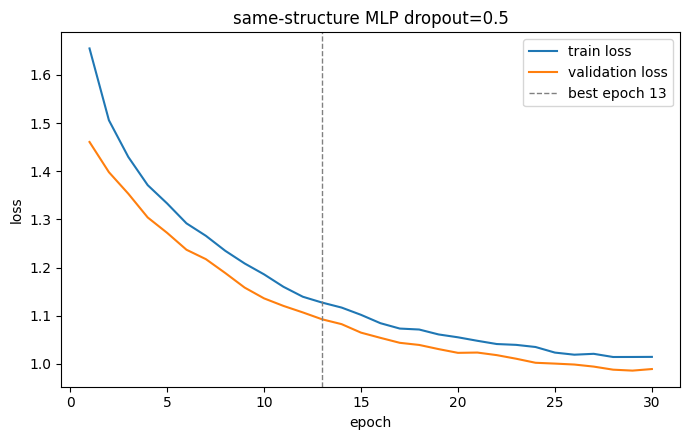


===== dropout=0.4 =====
Epoch 01/30 | train_loss=1.6255 | val_loss=1.4592 | acc=0.4521 | mae=0.6829 | f1=0.3192
Epoch 02/30 | train_loss=1.4842 | val_loss=1.3984 | acc=0.4827 | mae=0.6068 | f1=0.3379
Epoch 03/30 | train_loss=1.4114 | val_loss=1.3557 | acc=0.5018 | mae=0.5766 | f1=0.3437
Epoch 04/30 | train_loss=1.3577 | val_loss=1.3042 | acc=0.5023 | mae=0.5712 | f1=0.3441
Epoch 05/30 | train_loss=1.3238 | val_loss=1.2729 | acc=0.5214 | mae=0.5333 | f1=0.3339
Epoch 06/30 | train_loss=1.2794 | val_loss=1.2364 | acc=0.5461 | mae=0.5046 | f1=0.3349
Epoch 07/30 | train_loss=1.2561 | val_loss=1.2187 | acc=0.5351 | mae=0.5155 | f1=0.3265
Epoch 08/30 | train_loss=1.2231 | val_loss=1.1870 | acc=0.5388 | mae=0.5123 | f1=0.3309
Epoch 09/30 | train_loss=1.1950 | val_loss=1.1582 | acc=0.5420 | mae=0.5091 | f1=0.3350
Epoch 10/30 | train_loss=1.1684 | val_loss=1.1327 | acc=0.5543 | mae=0.4936 | f1=0.3399
Epoch 11/30 | train_loss=1.1452 | val_loss=1.1189 | acc=0.5602 | mae=0.4881 | f1=0.3299
Epoch 1

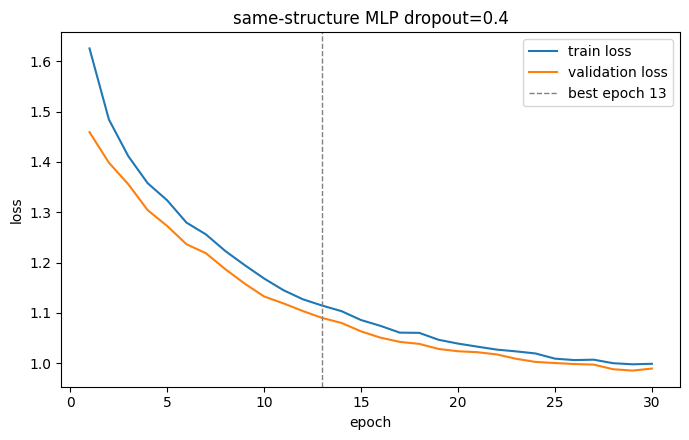


===== dropout=0.3 =====
Epoch 01/30 | train_loss=1.5995 | val_loss=1.4599 | acc=0.4507 | mae=0.6866 | f1=0.3207
Epoch 02/30 | train_loss=1.4685 | val_loss=1.4003 | acc=0.4767 | mae=0.6236 | f1=0.3346
Epoch 03/30 | train_loss=1.3955 | val_loss=1.3549 | acc=0.5023 | mae=0.5776 | f1=0.3444
Epoch 04/30 | train_loss=1.3511 | val_loss=1.3054 | acc=0.5014 | mae=0.5730 | f1=0.3453
Epoch 05/30 | train_loss=1.3102 | val_loss=1.2690 | acc=0.5210 | mae=0.5411 | f1=0.3330
Epoch 06/30 | train_loss=1.2691 | val_loss=1.2348 | acc=0.5397 | mae=0.5100 | f1=0.3340
Epoch 07/30 | train_loss=1.2400 | val_loss=1.2175 | acc=0.5360 | mae=0.5169 | f1=0.3264
Epoch 08/30 | train_loss=1.2092 | val_loss=1.1868 | acc=0.5433 | mae=0.5100 | f1=0.3400
Epoch 09/30 | train_loss=1.1829 | val_loss=1.1583 | acc=0.5465 | mae=0.5059 | f1=0.3319
Epoch 10/30 | train_loss=1.1578 | val_loss=1.1332 | acc=0.5525 | mae=0.4954 | f1=0.3402
Epoch 11/30 | train_loss=1.1344 | val_loss=1.1170 | acc=0.5566 | mae=0.4922 | f1=0.3314
Epoch 1

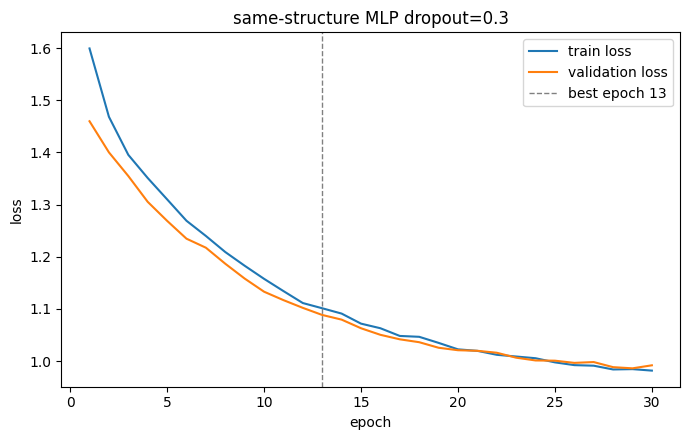


===== dropout=0.2 =====
Epoch 01/30 | train_loss=1.5812 | val_loss=1.4613 | acc=0.4466 | mae=0.7003 | f1=0.3194
Epoch 02/30 | train_loss=1.4541 | val_loss=1.3982 | acc=0.4758 | mae=0.6259 | f1=0.3359
Epoch 03/30 | train_loss=1.3829 | val_loss=1.3562 | acc=0.4982 | mae=0.5849 | f1=0.3388
Epoch 04/30 | train_loss=1.3388 | val_loss=1.3048 | acc=0.5046 | mae=0.5716 | f1=0.3493
Epoch 05/30 | train_loss=1.2963 | val_loss=1.2691 | acc=0.5246 | mae=0.5333 | f1=0.3355
Epoch 06/30 | train_loss=1.2582 | val_loss=1.2355 | acc=0.5360 | mae=0.5160 | f1=0.3381
Epoch 07/30 | train_loss=1.2264 | val_loss=1.2182 | acc=0.5342 | mae=0.5196 | f1=0.3296
Epoch 08/30 | train_loss=1.1926 | val_loss=1.1864 | acc=0.5516 | mae=0.4995 | f1=0.3480
Epoch 09/30 | train_loss=1.1670 | val_loss=1.1613 | acc=0.5461 | mae=0.5096 | f1=0.3330
Epoch 10/30 | train_loss=1.1436 | val_loss=1.1332 | acc=0.5561 | mae=0.4945 | f1=0.3380
Epoch 11/30 | train_loss=1.1191 | val_loss=1.1176 | acc=0.5534 | mae=0.4973 | f1=0.3338
Epoch 1

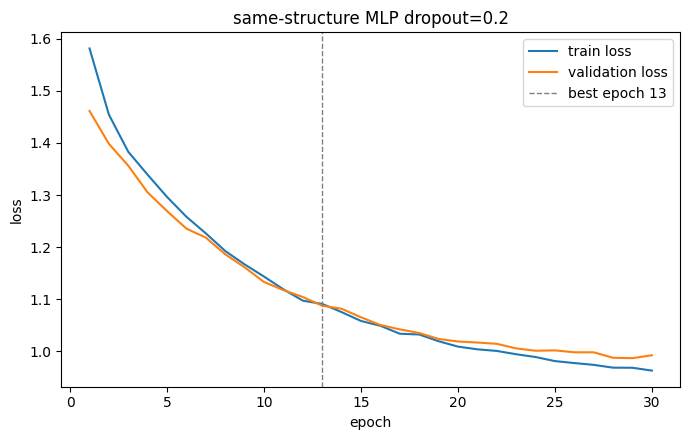

In [6]:
results = {}
for dropout in DROPOUT_VALUES:
    exp_name = f'same_structure_similarity_dropout_{dropout:.1f}'
    results[exp_name] = train_one_dropout(dropout)

## 결과 요약

In [7]:
summary_rows = []
for exp_name, res in results.items():
    row = {'experiment': exp_name}
    row.update(res['metrics'])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['f1_macro', 'acc', 'mae'], ascending=[False, False, True]).reset_index(drop=True)
summary_df.to_csv(OUT_DIR / 'summary_metrics_dropout_sweep.csv', index=False, encoding='utf-8-sig')
display(summary_df.round(4))

,experiment,acc,mae,mse,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,best_epoch,dropout
0,same_structure_similarity_dropout_0.2,0.5680,0.4872,0.6095,0.5059,0.3369,0.3640,0.5588,0.5680,0.5537,13,0.2
1,same_structure_similarity_dropout_0.3,0.5643,0.4881,0.6058,0.4733,0.3288,0.3539,0.5538,0.5643,0.5480,13,0.3
2,same_structure_similarity_dropout_0.4,0.5630,0.4868,0.5953,0.4994,0.3256,0.3518,0.5509,0.5630,0.5458,13,0.4
3,same_structure_similarity_dropout_0.7,0.5123,0.5652,0.7368,0.3626,0.3568,0.3487,0.5399,0.5123,0.5149,3,0.7
4,same_structure_similarity_dropout_0.5,0.5589,0.4891,0.5940,0.4806,0.3221,0.3483,0.5496,0.5589,0.5409,13,0.5
5,same_structure_similarity_dropout_0.6,0.5064,0.5725,0.7495,0.3494,0.3518,0.3413,0.5373,0.5064,0.5111,3,0.6
6,same_structure_similarity_dropout_0.8,0.5333,0.5233,0.6464,0.3702,0.3441,0.3397,0.5499,0.5333,0.5290,5,0.8


## Best experiment 상세 분석 및 저장

In [8]:
best_exp = summary_df.iloc[0]['experiment']
best = results[best_exp]
y_true = best['predictions']['y_true']
y_pred = best['predictions']['y_pred']
y_prob = best['predictions']['y_prob']

true_labels = y_true + 1
pred_labels = y_pred + 1

cm = pd.DataFrame(
    confusion_matrix(true_labels, pred_labels, labels=LABELS),
    index=[f'true_{x}' for x in LABELS],
    columns=[f'pred_{x}' for x in LABELS],
)
report_text = classification_report(
    true_labels,
    pred_labels,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    zero_division=0,
)
report_dict = classification_report(
    true_labels,
    pred_labels,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    output_dict=True,
    zero_division=0,
)

cm.to_csv(OUT_DIR / 'best_confusion_matrix.csv', encoding='utf-8-sig')
(OUT_DIR / 'best_classification_report.txt').write_text(report_text, encoding='utf-8')
pd.DataFrame(report_dict).T.to_csv(OUT_DIR / 'best_classification_report.csv', encoding='utf-8-sig')

pred_df = pd.DataFrame({
    'sound_id': df.loc[val_idx, 'sound_id'].values,
    'true_confidence': true_labels,
    'pred_confidence': pred_labels,
    'correct': true_labels == pred_labels,
    'pred_confidence_prob': y_prob.max(axis=1),
})
for i in range(5):
    pred_df[f'prob_confidence_{i + 1}'] = y_prob[:, i]
pred_df.to_csv(OUT_DIR / f'best_predictions_{best_exp}.csv', index=False, encoding='utf-8-sig')

torch.save({
    'experiment': best_exp,
    'model_state_dict': best['model'].state_dict(),
    'metrics': best['metrics'],
    'feature_description': FEATURE_DESCRIPTION,
    'model_description': MODEL_DESCRIPTION,
    'input_dim': int(X_full.shape[1]),
    'num_outputs': 5,
    'labels': LABELS,
    'dropout_values': DROPOUT_VALUES,
    'selected_dropout': float(best['dropout']),
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'scalar_feature_cols': SCALAR_FEATURE_COLS,
    'class_categories': class_categories,
}, OUT_DIR / f'best_model_{best_exp}.pt')

summary_json = {
    'best_experiment': best_exp,
    'feature_description': FEATURE_DESCRIPTION,
    'model_description': MODEL_DESCRIPTION,
    'audio_embedding_dim': int(audio_emb.shape[1]),
    'text_embedding_dim': int(text_emb.shape[1]),
    'class_onehot_dim': int(class_onehot.shape[1]),
    'scalar_feature_dim': int(scalar_features.shape[1]),
    'total_input_dim': int(X_full.shape[1]),
    'dropout_values': DROPOUT_VALUES,
    'metrics': json.loads(summary_df.to_json(orient='records')),
}
(OUT_DIR / 'summary.json').write_text(json.dumps(summary_json, indent=2, ensure_ascii=False), encoding='utf-8')

report_lines = []
report_lines.append('# Same-Structure MLP Confidence Classification Report')
report_lines.append('')
report_lines.append('## Model')
report_lines.append(f'- {MODEL_DESCRIPTION}')
report_lines.append('- This matches the actual SimpleMLP code in `bsd10k_confidence_mlp_colab.ipynb`.')
report_lines.append('')
report_lines.append('## Input features')
report_lines.append(f'- {FEATURE_DESCRIPTION}')
report_lines.append(f'- total input dim: {X_full.shape[1]}')
report_lines.append('')
report_lines.append('## Dropout sweep metrics')
report_lines.append('```text')
report_lines.append(summary_df.round(4).to_string(index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Best classification report')
report_lines.append('```text')
report_lines.append(report_text)
report_lines.append('```')
report_lines.append('')
report_lines.append('## Best confusion matrix')
report_lines.append('```text')
report_lines.append(cm.to_string())
report_lines.append('```')
(OUT_DIR / 'same_structure_mlp_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('Best experiment:', best_exp)
display(cm)
print(report_text)
print('saved outputs:', OUT_DIR)

Best experiment: same_structure_similarity_dropout_0.2


,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,1,1,7,12,0
true_2,1,24,63,61,1
true_3,0,18,325,308,5
true_4,0,10,308,852,40
true_5,0,0,12,100,43


              precision    recall  f1-score   support

confidence_1       0.50      0.05      0.09        21
confidence_2       0.45      0.16      0.24       150
confidence_3       0.45      0.50      0.47       656
confidence_4       0.64      0.70      0.67      1210
confidence_5       0.48      0.28      0.35       155

    accuracy                           0.57      2192
   macro avg       0.51      0.34      0.36      2192
weighted avg       0.56      0.57      0.55      2192

saved outputs: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\same_structure_mlp_confidence_outputs
